## Band-power Fisher: packed vs padded vs direct trace

Starting from the binned basis $P_b = S^T P_\ell$, we eigendecompose each band into rank-one vectors,
then compute the Fisher matrix three ways:
1. **Direct trace** — `Tr[M Pb_i M Pb_j]` (slow, full matrix products)
2. **Padded getF** — pad & stack into `(n_bands, max_rank, npix)`, use original `getF`
3. **Packed getF_packed** — `pack_basis` + `getF_packed` (no padding waste)

In [1]:
import sys
sys.path.insert(0, './')
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import opt_einsum as oe
from tqdm import tqdm
import time

from utilities import sph_harm_y_real_all, theta_phi, get_Pl_ij
from qmlfast import (
    getF, getF_packed, pack_basis, pack_sph_harm,
    block_np,
)

### Setup: single field, nside=16

In [2]:
nside = 16
lmax = 3 * nside - 1
ell = np.arange(lmax + 1, dtype=float)

s_aa = (ell + 1) ** (-2)
n_a = 1e-4
c_aa = s_aa + n_a

Nf = 1
omega_pix = 4 * np.pi / hp.nside2npix(nside)

### Mask

In [3]:
vec = hp.ang2vec(np.pi / 2, np.pi / 2)
ipix_disc = hp.query_disc(nside=nside, vec=vec, radius=np.radians(51))
vec1 = hp.ang2vec(np.pi / 3, 3 * np.pi / 2)
ipix_disc1 = hp.query_disc(nside=nside, vec=vec1, radius=np.radians(47))
mask = np.ones(hp.nside2npix(nside))
mask[ipix_disc] = 0.0
mask[ipix_disc1] = 0.0

theta, phi = theta_phi(nside)
theta = theta[mask == 1]
phi = phi[mask == 1]
Np = int(mask.sum())
print(f'Unmasked pixels: {Np}')

Unmasked pixels: 2008


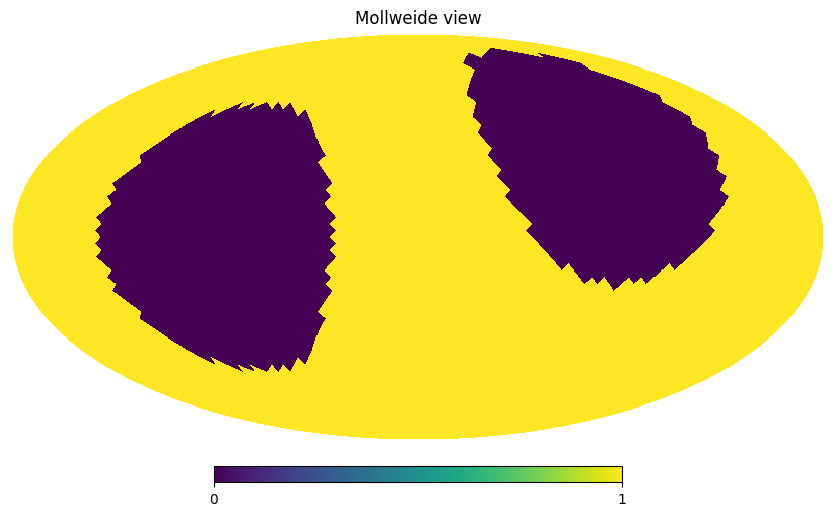

In [4]:
hp.mollview(mask)

### Pixel covariance and its inverse

In [ ]:
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

cov = get_pix_cov_block(s_aa, Pl_ij, 0, lmax + 1)
large_cov = cov + np.eye(Np) * n_a / omega_pix
M_true = np.linalg.inv(large_cov)

C_map = np.ones((1, 1))

### Reference: full ell-by-ell Fisher

In [6]:
Y_r_all = sph_harm_y_real_all(lmax, theta, phi)
F_idx_ell = np.array([(i, j, l) for l in range(lmax)
                      for i in range(Nf) for j in range(i, Nf)])

F_ell = getF(Y_r_all, M_true, F_idx_ell, Nf, Np, C_map)
print(f'F_ell shape: {F_ell.shape}')

VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.15it/s]


F_ell shape: (47, 47)


### Binning setup

In [7]:
nbands = 12
ells_per_band = lmax // nbands

Bbl = np.zeros((nbands, lmax))
leffs_low = np.arange(0, nbands * ells_per_band, ells_per_band)
leffs_top = leffs_low + ells_per_band
leffs = (leffs_top + leffs_low) / 2

for i in range(nbands):
    Bbl[i, i * ells_per_band:(i + 1) * ells_per_band] = 1.0 / ells_per_band

# Unbinning operator
S = Bbl.T @ np.linalg.inv(Bbl @ Bbl.T)

print(f'Bbl shape: {Bbl.shape}')
print(f'Bands: {nbands}, ells_per_band: {ells_per_band}')

Bbl shape: (12, 47)
Bands: 12, ells_per_band: 3


### Reference: F_ell binned after the fact
$$F_b = S^T F_\ell S$$

In [8]:
# Pl_ij is (lmax+1, Np, Np), we use [:-1] to match lmax modes
F_bandafter = S.T @ F_ell @ S
print(f'F_bandafter shape: {F_bandafter.shape}')

F_bandafter shape: (12, 12)


### Build binned basis Pb and eigendecompose into rank-one vectors

In [9]:
import fbpca

# Binned pixel-space basis: Pb_ij = S.T @ Pl_ij
Pb_ij = np.einsum('ij,jmn->imn', S.T, Pl_ij[:-1])  # (nbands, Np, Np)

def max_ncomp(band_idx, S):
    """Max rank = sum of (2*ell+1) for all ell in this band."""
    ells = np.where(S[:, band_idx] != 0)[0]
    return int(np.sum(2 * ells + 1))

# Eigendecompose each band
Evals = []
Evecs = []
for b in tqdm(range(nbands), desc='eigendecompose'):
    ncomp = max_ncomp(b, S)
    evals, evecs = fbpca.eigens(Pb_ij[b], k=ncomp)
    Evals.append(evals)
    Evecs.append(evecs)

eigendecompose: 100%|███████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:13<00:00,  1.11s/it]


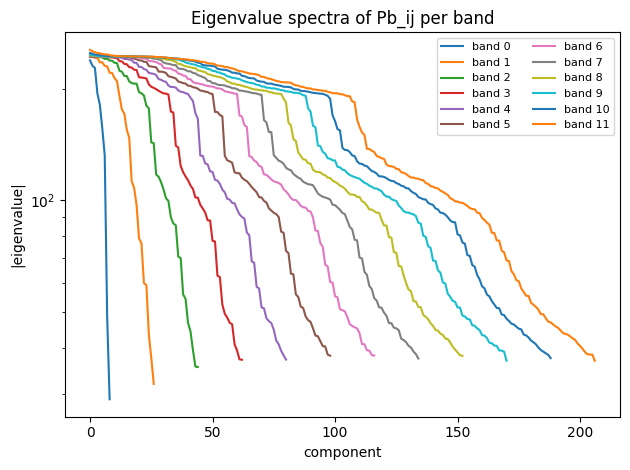

In [10]:
# Eigenvalue spectra per band
for b, evals in enumerate(Evals):
    plt.semilogy(np.abs(evals), label=f'band {b}')
plt.xlabel('component')
plt.ylabel('|eigenvalue|')
plt.title('Eigenvalue spectra of Pb_ij per band')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Build rank-one vectors with truncation

In [11]:
eps = 0.5  # keep eigenvalues > eps * max_eigenvalue

V_list = []  # for pack_basis
for b in range(nbands):
    ev = Evals[b]
    evec = Evecs[b]
    keep = np.abs(ev) / np.abs(ev[0]) > eps
    n_keep = int(np.sum(keep))
    # yb[k, :] = sqrt(|sigma_k|) * sign(sigma_k) * u_k
    # so that sum_k yb[k,i]*yb[k,j] ≈ Pb[i,j]
    signs = np.sign(ev[keep])
    yb = evec[:, keep] * np.sqrt(np.abs(ev[keep])).reshape(1, -1)
    V_list.append(yb.T)  # shape (n_keep, Np)
    print(f'  band {b:2d}: kept {n_keep:4d} / {len(ev):4d} components '
          f'({100*n_keep/len(ev):.0f}%)')

  band  0: kept    7 /    9 components (78%)
  band  1: kept   17 /   27 components (63%)
  band  2: kept   27 /   45 components (60%)
  band  3: kept   38 /   63 components (60%)
  band  4: kept   49 /   81 components (60%)
  band  5: kept   59 /   99 components (60%)
  band  6: kept   71 /  117 components (61%)
  band  7: kept   80 /  135 components (59%)
  band  8: kept   91 /  153 components (59%)
  band  9: kept  101 /  171 components (59%)
  band 10: kept  112 /  189 components (59%)
  band 11: kept  121 /  207 components (58%)


### Method 1: Direct trace (slow baseline)
$$F^{\text{direct}}_{b_1 b_2} = \frac{1}{2} \text{Tr}\left[M\, P_{b_1}\, M\, P_{b_2}\right]$$

In [12]:
t0 = time.perf_counter()

F_direct = np.zeros((nbands, nbands))
for i in range(nbands):
    MPi = M_true @ Pb_ij[i]
    for j in range(i, nbands):
        MPj = M_true @ Pb_ij[j]
        F_direct[i, j] = 0.5 * np.trace(MPi @ MPj)
        F_direct[j, i] = F_direct[i, j]

t_direct = time.perf_counter() - t0
print(f'Direct trace: {t_direct:.2f} s')

Direct trace: 14.29 s


### Method 2: Padded getF (old approach)
Pad & stack into `(nbands, max_rank, Np)` — lots of wasted zeros.

In [13]:
# Pad and stack (like the old notebook)
max_rank = max(v.shape[0] for v in V_list)
yb_padded = np.zeros((nbands, max_rank, Np))
for b, v in enumerate(V_list):
    yb_padded[b, :v.shape[0], :] = v

ranks_b = np.array([v.shape[0] for v in V_list], dtype=np.int64)
print(f'Padded shape: {yb_padded.shape}')
print(f'Actual ranks: {ranks_b}')
print(f'Padding waste: {100*(1 - ranks_b.sum() / (nbands * max_rank)):.0f}%')

Padded shape: (12, 121, 2008)
Actual ranks: [  7  17  27  38  49  59  71  80  91 101 112 121]
Padding waste: 47%


In [14]:
F_idx_b = np.array([(i, j, b) for b in range(nbands)
                     for i in range(Nf) for j in range(i, Nf)])

t0 = time.perf_counter()
F_padded = getF(yb_padded, M_true, F_idx_b, Nf, Np, C_map, ranks=ranks_b)
t_padded = time.perf_counter() - t0
print(f'Padded getF: {t_padded:.2f} s')

VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.54it/s]


Padded getF: 0.21 s


### Method 3: Packed getF_packed (new approach)
No padding — `pack_basis` stacks vectors tightly.

In [15]:
V_packed, offsets, ranks = pack_basis(V_list)

print(f'Packed shape: {V_packed.shape}')
print(f'Padded would be: ({nbands}, {max_rank}, {Np}) = '
      f'{nbands * max_rank * Np * 8 / 1e6:.1f} MB')
print(f'Packed is: {V_packed.shape} = {V_packed.nbytes / 1e6:.1f} MB')

Packed shape: (773, 2008)
Padded would be: (12, 121, 2008) = 23.3 MB
Packed is: (773, 2008) = 12.4 MB


In [16]:
t0 = time.perf_counter()
F_packed = getF_packed(V_packed, offsets, ranks, M_true, F_idx_b, Nf, Np, C_map)
t_packed = time.perf_counter() - t0
print(f'Packed getF_packed: {t_packed:.2f} s')

VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.98it/s]

Packed getF_packed: 0.19 s


### Consistency checks

In [17]:
def report(name_a, name_b, Fa, Fb):
    diff = np.max(np.abs(Fa - Fb))
    scale = np.max(np.abs(Fa)) + 1e-300
    rel = diff / scale
    status = 'PASS' if rel < 1e-6 else 'FAIL'
    print(f'  {name_a:20s} vs {name_b:20s}: '
          f'max|diff|={diff:.2e}, rel={rel:.2e}  [{status}]')

print('Method consistency:')
report('direct_trace', 'padded_getF', F_direct, F_padded)
report('direct_trace', 'packed_getF', F_direct, F_packed)
report('padded_getF', 'packed_getF', F_padded, F_packed)

print(f'\nTiming:')
print(f'  Direct trace:  {t_direct:.2f} s')
print(f'  Padded getF:   {t_padded:.2f} s')
print(f'  Packed getF:   {t_packed:.2f} s')

Method consistency:
  direct_trace         vs padded_getF         : max|diff|=6.50e+06, rel=9.97e-02  [FAIL]
  direct_trace         vs packed_getF         : max|diff|=6.50e+06, rel=9.97e-02  [FAIL]
  padded_getF          vs packed_getF         : max|diff|=0.00e+00, rel=0.00e+00  [PASS]

Timing:
  Direct trace:  14.29 s
  Padded getF:   0.21 s
  Packed getF:   0.19 s


### Compare band-first Fisher vs binned-after-the-fact Fisher

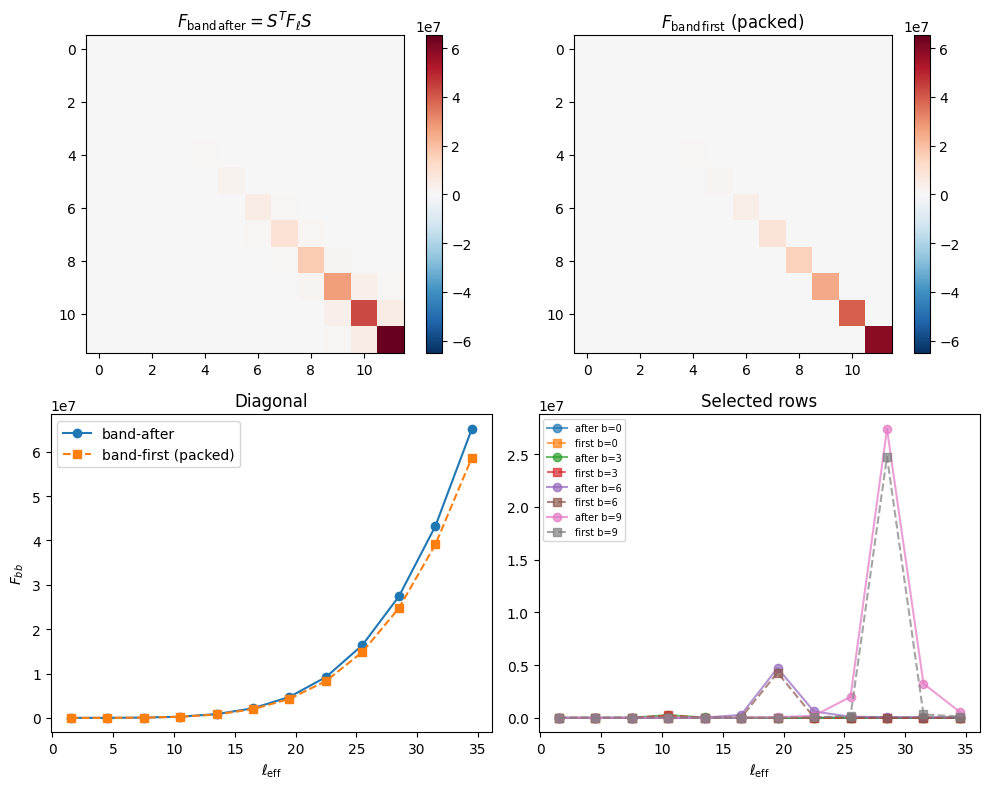

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# F matrices side by side
vmax = np.max(np.abs(F_bandafter))
im0 = axes[0, 0].imshow(F_bandafter, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0, 0].set_title(r'$F_{\rm band\,after} = S^T F_\ell S$')
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(F_packed, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0, 1].set_title(r'$F_{\rm band\,first}$ (packed)')
plt.colorbar(im1, ax=axes[0, 1])

# Diagonal comparison
axes[1, 0].plot(leffs, np.diag(F_bandafter), 'o-', label='band-after')
axes[1, 0].plot(leffs, np.diag(F_packed), 's--', label='band-first (packed)')
axes[1, 0].set_xlabel(r'$\ell_{\rm eff}$')
axes[1, 0].set_ylabel(r'$F_{bb}$')
axes[1, 0].legend()
axes[1, 0].set_title('Diagonal')

# Row-by-row comparison
for row in range(0, nbands, 3):
    axes[1, 1].plot(leffs, F_bandafter[row], 'o-', label=f'after b={row}', alpha=0.7)
    axes[1, 1].plot(leffs, F_packed[row], 's--', label=f'first b={row}', alpha=0.7)
axes[1, 1].set_xlabel(r'$\ell_{\rm eff}$')
axes[1, 1].legend(fontsize=7)
axes[1, 1].set_title('Selected rows')

plt.tight_layout()
plt.show()

### Memory comparison

In [19]:
mem_padded_input = nbands * max_rank * Np * 8
mem_packed_input = V_packed.nbytes

total_rank = int(ranks.sum())
mem_padded_VCinvV = nbands**2 * max_rank**2 * 8  # rough: 4D tensor
mem_packed_VCinvV = total_rank**2 * 8  # 2D packed

print('Basis vectors:')
print(f'  Padded: {mem_padded_input/1e6:.1f} MB  '
      f'({nbands} x {max_rank} x {Np})')
print(f'  Packed: {mem_packed_input/1e6:.1f} MB  '
      f'({total_rank} x {Np})')
print(f'  Ratio:  {mem_padded_input/mem_packed_input:.1f}x')
print()
print('VCinvV storage (per field pair):')
print(f'  Padded 4D: {mem_padded_VCinvV/1e6:.1f} MB  '
      f'({nbands} x {max_rank} x {nbands} x {max_rank})')
print(f'  Packed 2D: {mem_packed_VCinvV/1e6:.1f} MB  '
      f'({total_rank} x {total_rank})')
print(f'  Ratio:  {mem_padded_VCinvV/mem_packed_VCinvV:.1f}x')

Basis vectors:
  Padded: 23.3 MB  (12 x 121 x 2008)
  Packed: 12.4 MB  (773 x 2008)
  Ratio:  1.9x

VCinvV storage (per field pair):
  Padded 4D: 16.9 MB  (12 x 121 x 12 x 121)
  Packed 2D: 4.8 MB  (773 x 773)
  Ratio:  3.5x


### Explore truncation: fewer eigenmodes → smaller rank → faster

In [20]:
epsilons = [0.7, 0.5, 1e-1, 1e-2]
results = []

for eps in epsilons:
    V_list_trunc = []
    for b in range(nbands):
        ev = Evals[b]
        evec = Evecs[b]
        keep = np.abs(ev) / np.abs(ev[0]) > eps
        yb = evec[:, keep] * np.sqrt(np.abs(ev[keep])).reshape(1, -1)
        V_list_trunc.append(yb.T)

    Vp, off, rk = pack_basis(V_list_trunc)
    total_r = int(rk.sum())

    t0 = time.perf_counter()
    F_trunc = getF_packed(Vp, off, rk, M_true, F_idx_b, Nf, Np, C_map)
    dt = time.perf_counter() - t0

    err = np.max(np.abs(F_trunc - F_direct)) / np.max(np.abs(F_direct))
    results.append((eps, total_r, dt, err))
    print(f'eps={eps}: total_rank={total_r:5d}, '
          f'time={dt:.2f}s, rel_err={err:.2e}')

print('\n(rel_err is vs the direct trace with full eigendecomposition)')

VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.72it/s]


eps=0.7: total_rank=  689, time=0.20s, rel_err=1.41e-01


VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.56it/s]


eps=0.5: total_rank=  773, time=0.19s, rel_err=9.97e-02


VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.32it/s]


eps=0.1: total_rank= 1296, time=0.21s, rel_err=3.09e-15


VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.29it/s]


eps=0.01: total_rank= 1296, time=0.22s, rel_err=3.09e-15

(rel_err is vs the direct trace with full eigendecomposition)


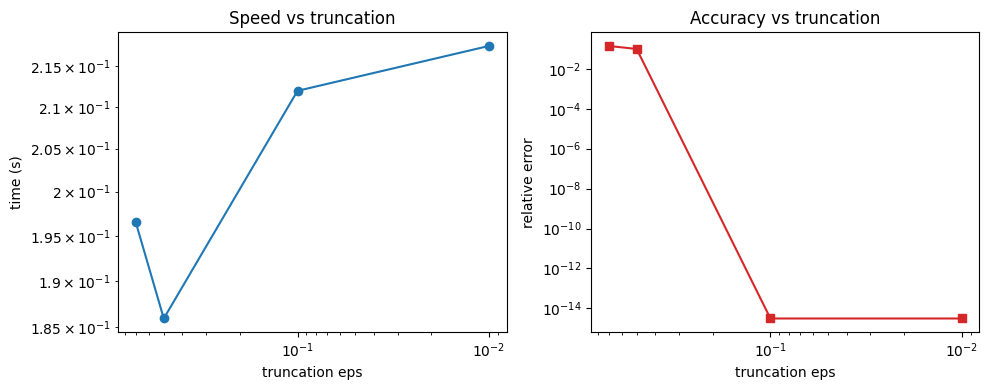

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

eps_vals = [r[0] for r in results]
ranks_vals = [r[1] for r in results]
times_vals = [r[2] for r in results]
errs_vals = [r[3] for r in results]

ax1.loglog(eps_vals, times_vals, 'o-')
ax1.set_xlabel('truncation eps')
ax1.set_ylabel('time (s)')
ax1.set_title('Speed vs truncation')
ax1.invert_xaxis()

ax2.loglog(eps_vals, errs_vals, 's-', color='tab:red')
ax2.set_xlabel('truncation eps')
ax2.set_ylabel('relative error')
ax2.set_title('Accuracy vs truncation')
ax2.invert_xaxis()

plt.tight_layout()
plt.show()